In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import os
import yaml
from pathlib import Path
from dask.distributed import Client
import dask.dataframe as dd
import networkx as nx
import sys
import pandas as pd


import ipycytoscape
import ipywidgets as widgets
from cytoscape_functions import *
from graph_functions import *
import matplotlib.pyplot as plt
import numpy as np
from plotsA import *
import intervals
import pygtrie
import seaborn as sns

/usr/workspace/pandey2/DFtracer/envdft/lib/python3.9/site-packages/dask/dataframe/__init__.py:49: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [3]:
# App Name
app_name = "mummi" # resnet cosmoflow unet3d mummi deepspeed dlio_resnet dlio_cosmoflow
# app_name = "montage"
# app_name = "deepspeed2"
cp_dir = "/p/lustre2/pandey2/cp_dir"

In [6]:

use_local=False
if not use_local:
    with open(f'/g/g91/pandey2/.dftracer/configuration.yaml', 'r') as file:
    # 1 with open(f'/g/g91/pandey2/.dlio_profiler/configuration.yaml', 'r') as file:
        dlp_yaml = yaml.safe_load(file)
        app_root = dlp_yaml["app"]
else:
    app_root = str(Path(os.getcwd()).parent.parent)
sys.path.insert(0, app_root)


import dfanalyzer
print(dfanalyzer.__file__)
from dfanalyzer.main import DFAnalyzer,get_dft_configuration,update_dft_configuration,setup_logging,setup_dask_cluster, reset_dask_cluster, get_dft_configuration
from dfanalyzer.graph_visualization.plots import GrepIOPlots
from dfanalyzer.graph import GrepIO 

if not use_local:
    dask_run_dir = os.path.join(app_root, "dfanalyzer", "dask", "run_dir")
    with open (os.path.join(dask_run_dir, f"scheduler_{os.getenv('USER')}.json"), "r") as f:
        dask_scheduler = json.load(f)["address"]
else:
    dask_scheduler = None


def get_conditions_cosmoflow(json_object):
    app_io_cond = "TFReader.parse_image" in json_object["name"] # Cosmoflow
    compute_cond = "compute" in json_object["name"] # Cosmoflow
    io_cond = "POSIX" == json_object["cat"] # Cosmoflow
    return app_io_cond, compute_cond, io_cond

def get_conditions_resnet(json_object):
    app_io_cond = "IO" == json_object["cat"] # Resnet50
    compute_cond = "cpu" in json_object["name"] or "compute" in json_object["cat"] # Resnet50
    io_cond = "POSIX" == json_object["cat"] # Cosmoflow
    return app_io_cond, compute_cond, io_cond

def get_conditions_unet3d(json_object):
    app_io_cond = "NPZReader.read_index" in json_object["name"] # Unet3d
    compute_cond = "compute" in json_object["name"] # Unet3d
    io_cond = "POSIX" == json_object["cat"] # Cosmoflow
    return app_io_cond, compute_cond, io_cond

def get_conditions_dlio_resnet(json_object):
    app_io_cond = "read_index" in json_object["name"] # Unet3d
    compute_cond = "compute" in json_object["name"] # Unet3d
    io_cond = "POSIX" == json_object["cat"] # Cosmoflow
    return app_io_cond, compute_cond, io_cond


condition_fn = None #

if app_name == "mummi":
    filename = "/usr/workspace/iopp/graph-io/dlp_logs/mummi-32-node/*pfw.gz"

elif app_name == "montage":
    filename ="/usr/workspace/iopp/graph-io/dlp_logs/montage_16_48ppn/montage*.pfw"

elif app_name == "deepspeed":
    filename = "/usr/workspace/iopp/dlp_traces/deepspeed_8_4ppn/*.pfw.gz"

    
elif app_name == "deepspeed1": #deepspeed low interference
    filename = "/usr/workspace/iopp/graph-io/dlp_logs/deepspeed_2_node_low_interference/*.pfw.gz"

elif app_name == "deepspeed2": # deepspeed high interference
    filename = "/usr/workspace/iopp/graph-io/dlp_logs/deepspeed_2_node_high_interference/*.pfw.gz"

elif app_name == "cosmoflow":#empty traces do not run yet
    filename = "/usr/WS2/iopp/kogiou1/dlio_benchmark/hydra_log/cosmoflow/2023-10-31-10-27-24/.trace*.pfw.gz"
    condition_fn = get_conditions_cosmoflow

elif app_name == "node32":#empty traces do not run yet
    filename = "/usr/workspace/iopp/dlp_traces/node_32_ppn_4/.trace*.pfw.gz"

elif app_name == "resnet":
    filename = "/usr/workspace/iopp/dlp_traces/resnet_50_1node_4ppn/*.pfw.gz"
    condition_fn = get_conditions_dlio_resnet

else:
    raise Exception("Unknown App name")


# Configuration 4 update log file dlp -> df
conf = update_dft_configuration(dask_scheduler=dask_scheduler, verbose=True, 
                                log_file=f"./dft_{os.getenv('USER')}.log", rebuild_index=False, time_approximate=False, 
                                host_pattern=r'lassen(\d+)', time_granularity=30e6, skip_hostname=True, conditions=condition_fn)
conf = get_dft_configuration()


# Setup
setup_logging()
setup_dask_cluster()
reset_dask_cluster()

[INFO] [09:29:02] Initialized Client with 192 workers and link http://134.9.71.28:8787/status [/usr/workspace/pandey2/DFtracer1/dftracer/dfanalyzer/main.py:672]


/usr/workspace/pandey2/DFtracer1/dftracer/dfanalyzer/__init__.py


[INFO] [09:29:08] Restarting all workers [/usr/workspace/pandey2/DFtracer1/dftracer/dfanalyzer/main.py:664]


In [4]:
# This cell is for mount point detection functions

def find_mount_point(path,trie):
    mount_point = trie.longest_prefix(path)
    if mount_point:
        return mount_point.key
    return "/"

def all_mount_points():
    with open("/proc/mounts", "r") as file:
        mount_points = [line.split()[1] for line in file]
    with open("/usr/workspace/pandey2/lassen_mounts", "r") as file:
        mount_p = [line.split()[1] for line in file]
    return mount_points+mount_p

mount_points = all_mount_points()
trie = pygtrie.StringTrie(zip(mount_points, [True] * len(mount_points)))

def mummi_cols_function(json_object, current_dict, time_approximate,condition_fn,load_data):
    d = {}
    def find_mount_point(path,trie):
        mount_point = trie.longest_prefix(path)
        if mount_point:
            return mount_point.key
        return "/"
    
    if "args" in json_object:
        if "path" in json_object["args"]:
            d["path"] = str(json_object["args"]["path"])
        if "filename" in json_object["args"]:
            d["filename"] = str(json_object["args"]["filename"])   
            d["mount_point"] = find_mount_point(trie=load_data["mount_point"],path=str(json_object["args"]["filename"]))
        if "flags" in json_object["args"]:
            d['flags'] = int(json_object["args"]["flags"])
        if "mode" in json_object["args"]:
            d['mode'] = int(json_object["args"]["mode"])
          
    return d


def montage_cols_function(json_object, current_dict, time_approximate,condition_fn,load_data):
    d = {}
    def find_mount_point(path,trie):
        mount_point = trie.longest_prefix(path)
        if mount_point:
            return mount_point.key
        return "/"
    
    if "args" in json_object:
        if "path" in json_object["args"]:
            d["path"] = str(json_object["args"]["path"])
        if "fname" in json_object["args"]:
            d["filename"] = str(json_object["args"]["fname"])   
            d["mount_point"] = find_mount_point(trie=load_data["mount_point"],path=str(json_object["args"]["fname"]))
        if "flags" in json_object["args"]:
            d['flags'] = int(json_object["args"]["flags"])
        if "mode" in json_object["args"]:
            d['mode'] = int(json_object["args"]["mode"])
          
    return d

def deepspeed_cols_function(json_object, current_dict, time_approximate,condition_fn,load_data):
    d = {}
    def find_mount_point(path,trie):
        mount_point = trie.longest_prefix(path)
        if mount_point:
            return mount_point.key
        return "/"
    
    if "args" in json_object:
        if "fname" in json_object["args"]:
            d["mount_point"] = find_mount_point(trie=load_data["mount_point"],path=str(json_object["args"]["fname"]))
          
    return d

load_cols_mummi = {'path':"string[pyarrow]", 'filename':"string[pyarrow]",'mount_point':"string[pyarrow]", 'flags':"uint64[pyarrow]", 'mode':"uint64[pyarrow]"}
load_cols_montage = {'path':"string[pyarrow]", 'filename':"string[pyarrow]",'mount_point':"string[pyarrow]", 'flags':"uint64[pyarrow]", 'mode':"uint64[pyarrow]"}
load_cols_deepspeed = {'mount_point':"string[pyarrow]"}

In [7]:
#Change
analyzer_mummi1 = DFAnalyzer(filename,load_fn=mummi_cols_function, load_cols=load_cols_mummi, load_data={"mount_point":trie})
# analyzer_deepspeed1 = DFAnalyzer(filename,load_fn=deepspeed_cols_function, load_cols=load_cols_deepspeed, load_data={"mount_point":trie})
# analyzer_deepspeed1 = DFAnalyzer(filename)

[INFO] [09:29:19] Created index for 5850 files [/usr/workspace/pandey2/DFtracer1/dftracer/dfanalyzer/main.py:370]
[INFO] [09:29:19] Total size of all files are <dask.bag.core.Item object at 0x1555417af460> bytes [/usr/workspace/pandey2/DFtracer1/dftracer/dfanalyzer/main.py:372]
[INFO] [09:29:21] Loading 6106 batches out of 5850 files and has 4506578 lines overall [/usr/workspace/pandey2/DFtracer1/dftracer/dfanalyzer/main.py:385]
[INFO] [09:29:49] Loaded events [/usr/workspace/pandey2/DFtracer1/dftracer/dfanalyzer/main.py:430]
[INFO] [09:29:49] Loaded plots with slope threshold: 45 [/usr/workspace/pandey2/DFtracer1/dftracer/dfanalyzer/main.py:436]


In [7]:
#for deepspeed
# analyzer_deepspeed1.events['id'] = analyzer_deepspeed1.events.index
# deepspeed1DDf = GrepIO(analyzer_deepspeed1.events, app_name="deepspeed2", cp_dir=cp_dir)
# eventsDF = analyzer_deepspeed1.events[analyzer_deepspeed1.events['cat'] == "POSIX" ] # only posix events
# eventsDF['id'] = eventsDF.index
# deepspeed1DDf = GrepIO(eventsDF, app_name="deepspeed2")
# deepspeed1DDf.get_degree()
# deepspeed1DDf.get_interference()
# deepspeed1DDf.write_checkpoint(id = "inter", cp_dir= cp_dir)
# deepspeed1DDf.write_checkpoint(id = "ddf_deg", cp_dir= cp_dir)


In [12]:
#for mummi
# analyzer_mummi1.events['id'] = analyzer_mummi1.events.index
# mummi1DDf = GrepIO(analyzer_mummi1.events, app_name="mummi", cp_dir= cp_dir)
# mummi1DDf.get_degree()
# mummi1DDf.get_interference()
# mummi1DDf.write_checkpoint(id="inter", cp_dir=cp_dir)

In [18]:
mummi1DDf.ddf_deg.head()

,id,name,pid,size,ts,te,mount_point,dur,trange,deg
0,15000,read,104999,8192,330642476,330642491,/p/gpfs1,15,11,1
1,15001,read,104999,8192,330642602,330642612,/p/gpfs1,10,11,1
2,15002,read,104999,8192,330642699,330642708,/p/gpfs1,9,11,1
3,15003,read,104999,1506,330642793,330642802,/p/gpfs1,9,11,1
4,15018,write,104999,33854,330964072,330964253,/p/gpfs1,181,11,1


In [20]:
mummi1DDf.ddf_deg.dtypes

id             string[pyarrow]
name           string[pyarrow]
pid                      int64
size                     int64
ts                       int64
te                       int64
mount_point    string[pyarrow]
dur                      int64
trange                   int64
deg                      int64
dtype: object

In [13]:
mummi1DDf.get_degree()

In [14]:
mummi1DDf.get_interference()

In [15]:
mummi1DDf.ddf_deg.head()

,id,name,pid,size,ts,te,mount_point,dur,trange,deg
0,15000,read,104999,8192,330642476,330642491,/p/gpfs1,15,11,1
1,15001,read,104999,8192,330642602,330642612,/p/gpfs1,10,11,1
2,15002,read,104999,8192,330642699,330642708,/p/gpfs1,9,11,1
3,15003,read,104999,1506,330642793,330642802,/p/gpfs1,9,11,1
4,15018,write,104999,33854,330964072,330964253,/p/gpfs1,181,11,1


In [17]:
mummi1DDf.write_checkpoint(id="inter", cp_dir=cp_dir)

In [13]:
eventsDF.head()

,name,cat,pid,tid,ts,te,dur,tinterval,trange,hostname,compute_time,io_time,app_io_time,total_time,filename,phase,size,mount_point,id
2,opendir,POSIX,0,1740017,177303,220005,42702,"[1718662322810709,1718662322853411]",0,corona173,<NA>,"[1718662322810709,1718662322853411]",<NA>,"[1718662322810709,1718662322853411]",/p/lustre2/haridev/dlio/scr/dataset/scr_megatr...,2,<NA>,/p/lustre2,2
5,__xstat64,POSIX,0,1740017,220178,222983,2805,"[1718662322853584,1718662322856389]",0,corona173,<NA>,"[1718662322853584,1718662322856389]",<NA>,"[1718662322853584,1718662322856389]",/p/lustre2/haridev/dlio/scr/dataset/scr_megatr...,2,<NA>,/p/lustre2,5
6,__xstat64,POSIX,0,1740017,223019,223064,45,"[1718662322856425,1718662322856470]",0,corona173,<NA>,"[1718662322856425,1718662322856470]",<NA>,"[1718662322856425,1718662322856470]",/p/lustre2/haridev/dlio/scr/dataset/scr_megatr...,2,<NA>,/p/lustre2,6
10,opendir,POSIX,0,1740017,223346,235311,11965,"[1718662322856752,1718662322868717]",0,corona173,<NA>,"[1718662322856752,1718662322868717]",<NA>,"[1718662322856752,1718662322868717]",/p/lustre2/haridev/dlio/scr/dataset/scr_megatr...,2,<NA>,/p/lustre2,10
15,mkdir,POSIX,0,1740017,2621906,2621916,10,"[1718662325255312,1718662325255322]",0,corona173,<NA>,"[1718662325255312,1718662325255322]",<NA>,"[1718662325255312,1718662325255322]",/p/lustre2/haridev/dlio/scr/checkpoints/scr_me...,2,<NA>,/p/lustre2,15


In [14]:
deepspeed1DDf.ddf.head()

,id,name,pid,size,ts,te,mount_point,dur,trange
39,39,write,0,44,62068650,62068710,/p/lustre2,60,2
44,44,read,0,20,62075730,62077476,/p/lustre2,1746,2
45,45,read,0,47,62077489,62077493,/p/lustre2,4,2
47,47,write,0,67,62077516,62080595,/p/lustre2,3079,2
53,53,read,0,20,62092852,62101596,/p/lustre2,8744,2


In [15]:
deepspeed1DDf.get_degree()

In [16]:
deepspeed1DDf.ddf_deg.compute()

,id,name,pid,size,ts,te,mount_point,dur,trange,deg
0,10829,write,0,134217728,660590087,660950423,/p/lustre2,360336,22,1
1,13631,write,0,134217728,661006110,661369818,/p/lustre2,363708,22,1
2,105,write,0,134217728,661438391,661805701,/p/lustre2,367310,22,3
3,11235,write,12,134217728,661725733,662300105,/p/lustre2,574372,22,9
4,11014,write,15,134217728,661787472,662355067,/p/lustre2,567595,22,10
...,...,...,...,...,...,...,...,...,...,...
580,1532,write,0,134217728,1016927240,1017271769,/p/lustre2,344529,33,1
581,4492,write,0,134217728,1017327292,1017767067,/p/lustre2,439775,33,1
582,7360,write,0,134217728,1017850220,1018384076,/p/lustre2,533856,33,1
583,9923,write,0,134217728,1018467788,1018989776,/p/lustre2,521988,33,1


In [18]:
deepspeed1DDf.get_interference()

In [19]:
deepspeed1DDf.write_checkpoint(id = "inter", cp_dir= cp_dir)

In [21]:
deepspeed1DDf.write_checkpoint(id = "ddf_deg", cp_dir= cp_dir)

ValueError: Failed to convert partition to expected pyarrow schema:
    `ArrowNotImplementedError("NumPyConverter doesn't implement <large_string> conversion. ", 'Conversion failed for column id with type int64')`

Expected partition schema:
    id: large_string
    name: large_string
    pid: int64
    size: int64
    ts: int64
    te: int64
    mount_point: large_string
    dur: int64
    trange: int64
    deg: int64
    __null_dask_index__: int64

Received partition schema:
    id: int64
    name: large_string
    pid: uint64
    size: uint64
    ts: uint64
    te: uint64
    mount_point: large_string
    dur: uint64
    trange: uint16
    deg: int64
    __null_dask_index__: int64

This error *may* be resolved by passing in schema information for
the mismatched column(s) using the `schema` keyword in `to_parquet`.

In [49]:
deepspeed1DDf.write_checkpoint(cp_dir="/p/lustre2/pandey2",id="ddf_deg")

      id   name  pid        size          ts          te mount_point      dur  \
0    376   read    8  1875123200   510493555   511188363           /   694808   
1   5513   read    0  1875123200   511851041   512521415           /   670374   
2   3402   read    8  1875123200   516509871   517143252           /   633381   
3   9146   read    0  1875123200   517428519   518076141           /   647622   
4    893   read    8        1895   524385734   524385743           /        9   
..   ...    ...  ...         ...         ...         ...         ...      ...   
93  5554  write    8   150733735  1038196631  1038566368  /p/lustre2   369737   
94  1041  write    0  1875123200  1040213814  1045540166  /p/lustre2  5326352   
95  4094  write    8  1875123200  1040726715  1046117203  /p/lustre2  5390488   
96  4604  write    0  1875123200  1046205719  1051124022  /p/lustre2  4918303   
97  6970  write    8  1875123200  1046773380  1051645132  /p/lustre2  4871752   

    trange  deg  
0       1

ValueError: Failed to convert partition to expected pyarrow schema:
    `ArrowNotImplementedError("NumPyConverter doesn't implement <large_string> conversion. ", 'Conversion failed for column id with type int64')`

Expected partition schema:
    id: large_string
    name: large_string
    pid: int64
    size: int64
    ts: int64
    te: int64
    mount_point: large_string
    dur: int64
    trange: int64
    deg: int64
    __null_dask_index__: int64

Received partition schema:
    id: int64
    name: large_string
    pid: uint64
    size: uint64
    ts: uint64
    te: uint64
    mount_point: large_string
    dur: uint64
    trange: uint16
    deg: int64
    __null_dask_index__: int64

This error *may* be resolved by passing in schema information for
the mismatched column(s) using the `schema` keyword in `to_parquet`.

In [50]:
deepspeed1DDf.get_interference()

In [56]:
cp_dir = "/p/lustre2/pandey2/cp_dir/deepspeed1"

In [58]:
deepspeed1DDf.write_checkpoint(cp_dir=cp_dir,id="ddf_deg")

ValueError: Failed to convert partition to expected pyarrow schema:
    `ArrowNotImplementedError("NumPyConverter doesn't implement <large_string> conversion. ", 'Conversion failed for column id with type int64')`

Expected partition schema:
    id: large_string
    name: large_string
    pid: int64
    size: int64
    ts: int64
    te: int64
    mount_point: large_string
    dur: int64
    trange: int64
    deg: int64
    __null_dask_index__: int64

Received partition schema:
    id: int64
    name: large_string
    pid: uint64
    size: uint64
    ts: uint64
    te: uint64
    mount_point: large_string
    dur: uint64
    trange: uint16
    deg: int64
    __null_dask_index__: int64

This error *may* be resolved by passing in schema information for
the mismatched column(s) using the `schema` keyword in `to_parquet`.

In [26]:
deepspeed1DDf.ddf = deepspeed1DDf.ddf.query(f'name == POSIX')

ValueError: Metadata inference failed in `query`.

You have supplied a custom function and Dask is unable to 
determine the type of output that that function returns. 

To resolve this please provide a meta= keyword.
The docstring of the Dask function you ran should have more information.

Original error is below:
------------------------
UndefinedVariableError("name 'POSIX' is not defined")

Traceback:
---------
  File "/usr/workspace/pandey2/DFtracer/envdft/lib/python3.9/site-packages/dask/dataframe/utils.py", line 195, in raise_on_meta_error
    yield
  File "/usr/workspace/pandey2/DFtracer/envdft/lib/python3.9/site-packages/dask/dataframe/core.py", line 7175, in _emulate
    return func(*_extract_meta(args, True), **_extract_meta(kwargs, True))
  File "/usr/workspace/pandey2/DFtracer/envdft/lib/python3.9/site-packages/dask/utils.py", line 1241, in __call__
    return getattr(__obj, self.method)(*args, **kwargs)
  File "/usr/workspace/pandey2/DFtracer/envdft/lib/python3.9/site-packa

In [11]:
# mummi1DDf.ddf_deg.head()
deepspeed1DDf.ddf_deg.head()

,id,name,pid,size,ts,te,mount_point,dur,trange,deg


In [22]:
deepspeed1DDf.ddf.query(f'mount_point != "/p/lustre2" and mount_point != "/"').compute()

,id,name,pid,size,ts,te,mount_point,dur,trange
1898,1898,IndexedBinaryMMapReader.get_sample,0,2025,145526407,145526448,<NA>,41,4
1900,1900,IndexedBinaryMMapReader.close,0,2025,145526513,145526544,<NA>,31,4
1901,1901,IndexedBinaryMMapReader.read_index,0,2025,145525167,145526568,<NA>,1401,4
1911,1911,IndexedBinaryMMapReader.open,0,2025,145526664,145527532,<NA>,868,4
1912,1912,IndexedBinaryMMapReader.get_sample,0,2025,145527565,145527578,<NA>,13,4
...,...,...,...,...,...,...,...,...,...
1280,1280,IndexedBinaryMMapReader.read_index,9,2025,1253935226,1253936379,<NA>,1153,41
1290,1290,IndexedBinaryMMapReader.open,9,2025,1253936576,1253943243,<NA>,6667,41
1291,1291,IndexedBinaryMMapReader.get_sample,9,2025,1253943278,1253943292,<NA>,14,41
1293,1293,IndexedBinaryMMapReader.close,9,2025,1253943343,1253943369,<NA>,26,41


In [19]:
deepspeed1DDf.ddf['mount_point'].unique().compute()

0    /p/lustre2
1             /
2          <NA>
Name: mount_point, dtype: string

In [13]:
len(deepspeed1DDf.ddf)

KeyboardInterrupt: 

In [10]:
deepspeed1DDf.get_interference()

In [11]:
cp_dir = "/p/lustre2/pandey2/cp_dir"

In [9]:
deepspeed1DDf.ddf_deg.head()

,id,name,pid,size,ts,te,mount_point,dur,trange,deg


In [17]:
deepspeed1DDf.ddf_deg.head()

,id,name,pid,size,ts,te,mount_point,dur,trange,deg


In [12]:
deepspeed1DDf.write_checkpoint("deg_ddf",cp_dir=cp_dir)

AttributeError: 'NoneType' object has no attribute 'compute'

In [11]:
plot = GrepIOPlots()

KeyboardInterrupt: 

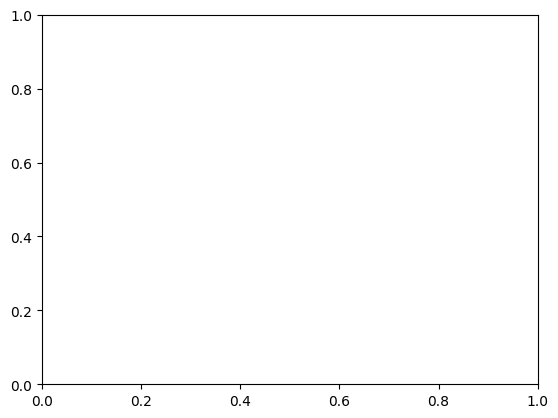

In [12]:
plot.histogram(analyzer_deepspeed1.events['size'],"size")